In [1]:
import pandas as pd
import os
os.chdir('../..')
os.getcwd()



'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

In [2]:
highLow = pd.read_csv('output/splitDecay/high/all_ame_output/ame.tsv',sep='\t')
llm = pd.read_csv('output/motifs/positive/ame_output/ame.tsv', sep='\t')


In [3]:

highLow = highLow[~highLow[['motif_alt_ID']].duplicated()]
llm = llm[~llm[['motif_alt_ID']].duplicated()]

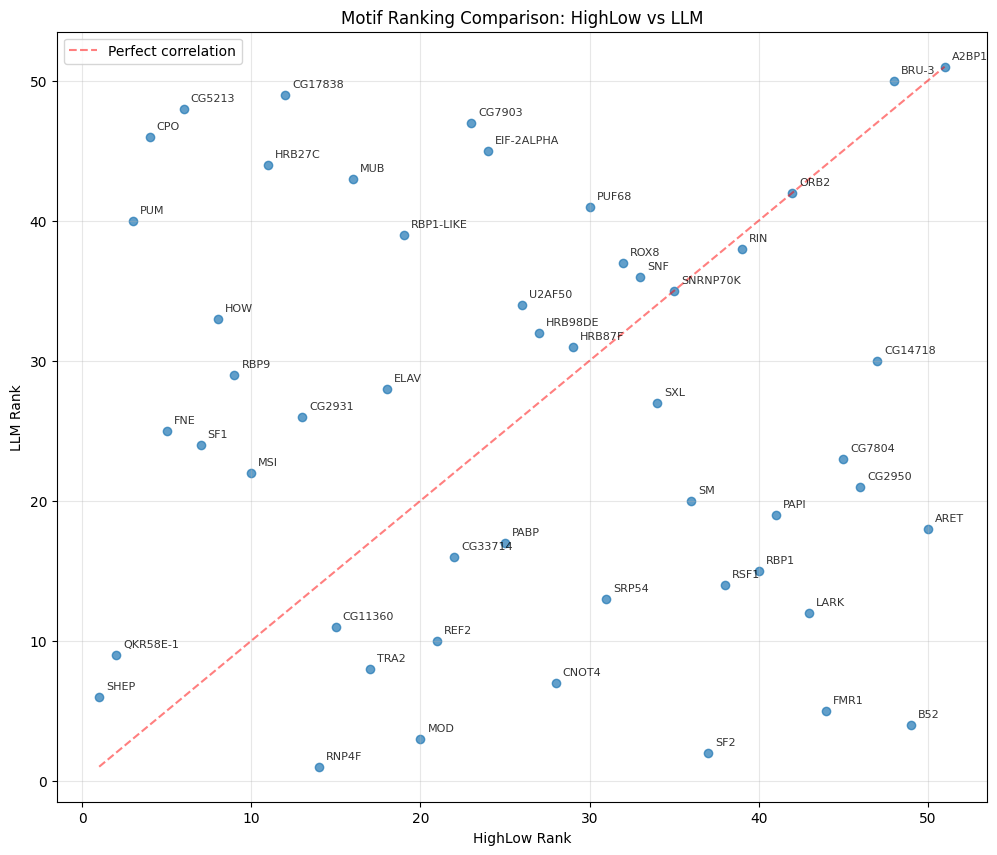

Number of common motifs: 51


In [5]:
import matplotlib.pyplot as plt

# Create rank columns for both dataframes
highLow_ranked = highLow.copy()
llm_ranked = llm.copy()

# Remove rows with NaN values in motif_alt_ID
highLow_ranked = highLow_ranked.dropna(subset=['motif_alt_ID'])
llm_ranked = llm_ranked.dropna(subset=['motif_alt_ID'])

# Create rank columns (1-indexed)
highLow_ranked['rank_num'] = range(1, len(highLow_ranked) + 1)
llm_ranked['rank_num'] = range(1, len(llm_ranked) + 1)

# Merge on motif_alt_ID to get common motifs
merged = pd.merge(highLow_ranked[['motif_alt_ID', 'rank_num']], 
                  llm_ranked[['motif_alt_ID', 'rank_num']], 
                  on='motif_alt_ID', 
                  suffixes=('_highLow', '_llm'))

# Create scatter plot
plt.figure(figsize=(12, 10))
plt.scatter(merged['rank_num_highLow'], merged['rank_num_llm'], alpha=0.7)

# Add motif_alt_ID labels to each point
for i, row in merged.iterrows():
    plt.annotate(row['motif_alt_ID'], 
                (row['rank_num_highLow'], row['rank_num_llm']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('HighLow Rank')
plt.ylabel('LLM Rank')
plt.title('Motif Ranking Comparison: HighLow vs LLM')

# Add diagonal line for reference
max_rank = max(merged['rank_num_highLow'].max(), merged['rank_num_llm'].max())
plt.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect correlation')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print number of common motifs
print(f"Number of common motifs: {len(merged)}")